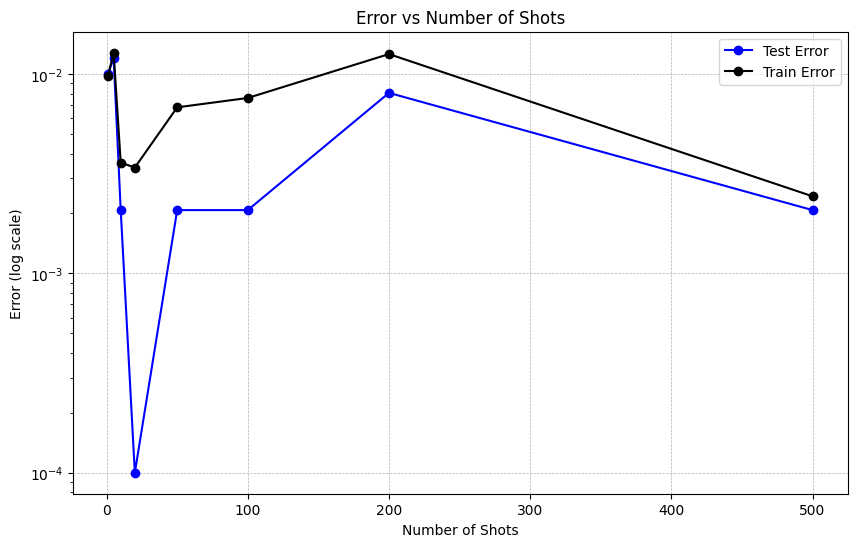

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
data = pd.read_csv("/home/yashsalunkhe619/directional_cdnv_bounds/results/clip/mini_imagenet/results.csv")

# parse accuracy strings robustly and ensure numeric
data['test_acc'] = data['test_acc'].astype(str).str.replace(r'[\[\]\s]', '', regex=True).astype(float)
data['train_acc'] = data['train_acc'].astype(str).str.replace(r'[\[\]\s]', '', regex=True).astype(float)

# compute error
data['test_error'] = 1.0 - data['test_acc']
data['train_error'] = 1.0 - data['train_acc']

# replace non-positive errors (0 or negative due to rounding) with a small floor for log plotting
FLOOR = 1e-4
data.loc[data['test_error'] <= 0.0, 'test_error'] = FLOOR
data.loc[data['train_error'] <= 0.0, 'train_error'] = FLOOR

# ensure n_shot is numeric and sorted
data['n_shot'] = pd.to_numeric(data['n_shot'], errors='coerce').astype(int)

# group and compute means, explicitly sorted by shot
grouped_test = data.groupby('n_shot', sort=True)['test_error'].mean().sort_index()
grouped_train = data.groupby('n_shot', sort=True)['train_error'].mean().sort_index()

# Plot the results
plt.figure(figsize=(10, 6))
plt.yscale('log')
plt.plot(grouped_test.index, grouped_test.values, marker='o', linestyle='-', color='b', label='Test Error')
plt.plot(grouped_train.index, grouped_train.values, marker='o', linestyle='-', color='k', label='Train Error')
plt.title('Error vs Number of Shots')
plt.xlabel('Number of Shots')
plt.ylabel('Error (log scale)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()


In [4]:
from bound_analysis.bound_core import compute_error_bound_for_m


import sys, os, argparse, yaml, pandas as pd


import torch
torch.set_default_dtype(torch.float32)
import random
from encoders.get_encoders import build_ssl_encoder
from data_utils.dataloaders import get_dataset
from eval_utils.feature_extractor import FeatureExtractor
from eval_utils.nccc_utils import NCCCEvaluator
def freeze_model(model):
    for param in model.parameters():
        param.requires_grad = False

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Ensures determinism




/home/yashsalunkhe619/miniconda3/envs/ssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
config_file = "/home/yashsalunkhe619/directional_cdnv_bounds/configs/ijepa_config.yaml"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(42)


#extract features
with open(config_file, 'r') as f:

        # load config
    config = yaml.safe_load(f)
    # build dataset
    num_output_classes = config['dataset']['num_output_classes']
    classes_group = random.sample(range(num_output_classes), 2)
    _, train_loader, _, test_loader, train_labels, test_labels = get_dataset(
        dataset_name=config['dataset']['name'],
        dataset_path=config['dataset']['path'],
        augment_both_views=config['linear']['augment_both'],
        batch_size=config['linear']['batch_size'],
        classes = classes_group,
        test=True,
    )

    ssl_model = build_ssl_encoder(
    method=config['method_type'],
    encoder_type=config['model']['encoder_type'],
    dataset=config['dataset']['name'],
    checkpoint=None,
    device=device,
)
    

In [6]:
from eval_utils.geometry import GeometricEvaluator

num_classes = config['dataset']['num_output_classes']
geometric_evaluator = GeometricEvaluator(num_classes=num_classes, device=device)

feature_extractor = FeatureExtractor(ssl_model, device=device)
train_features, train_labels = feature_extractor.extract_features(train_loader)
test_features, test_labels = feature_extractor.extract_features(test_loader)

cdnv = geometric_evaluator.compute_cdnv(train_features[0], train_labels)
directional_cdnv = geometric_evaluator.compute_directional_cdnv(train_features[0], train_labels)

print(f"CDNV: {cdnv}")
print(f"Directional CDNV: {directional_cdnv}")

Extracting Features: 100%|██████████| 1/1 [00:02<00:00,  2.50s/it]

CDNV: 2.27249813079834
Directional CDNV: 0.05846763774752617


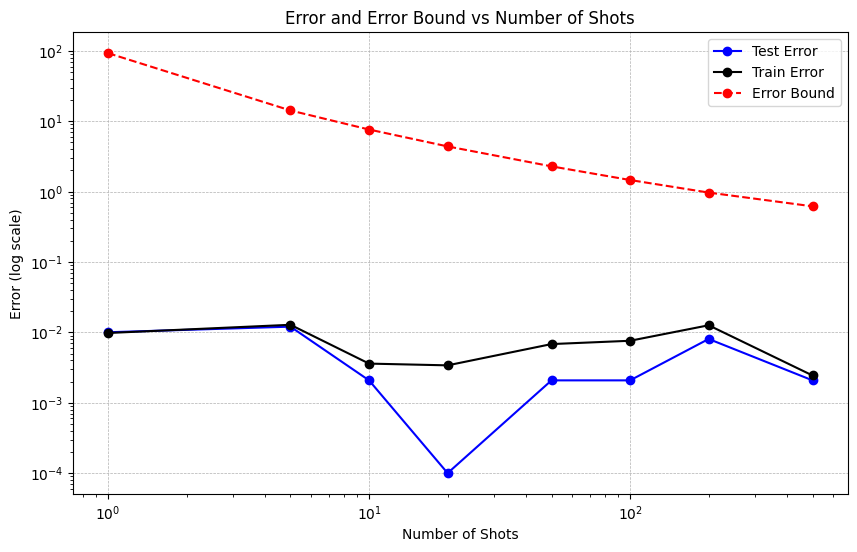

In [9]:
from bound_analysis.bound_core import compute_error_bound_for_m

m_shots = grouped_test.index  
error_bounds = [compute_error_bound_for_m(directional_cdnv, cdnv, m) for m in m_shots]

plt.figure(figsize=(10, 6))
plt.yscale('log')
plt.xscale('log')
plt.plot(m_shots, grouped_test.values, marker='o', linestyle='-', color='b', label='Test Error')
plt.plot(m_shots, grouped_train.values, marker='o', linestyle='-', color='k', label='Train Error')
plt.plot(m_shots, error_bounds, marker='o', linestyle='--', color='r', label='Error Bound')
plt.title('Error and Error Bound vs Number of Shots')
plt.xlabel('Number of Shots')
plt.ylabel('Error (log scale)')
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()